We need a U23 central midfielder for a possession-oriented Championship team with an estimated transfer fee not exceeding £5m (€5.85). The player should be from europes top 5 leagues and has to have played over 900 minutes in the 25/26 football season. 

Since the team is possession-oriented, midfielders that are better statistically at the progressive/ possession based attributes are likely to be a better fit for the team.

I was not able to find stats on FBref for many categories, meaning I couldn't build a complete profile for the considered midfielders. This forced me to find a different dataset that contained all the necessary statistics needed. The dataset I decided to use was from: https://github.com/m-mahadi/top5-football-dataset/blob/master/data/master/player_seasons.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

players = pd.read_csv('players.csv')
midfielders = players[players["pos"] == "MF"]
midfielders = midfielders[midfielders["age"] <= 23]
midfielders = midfielders[midfielders["playing_time_min"] >= 900]
midfielders = midfielders[midfielders["value_eur"] < 5850000]
midfielders = midfielders.drop(midfielders[midfielders["season_label"] == "2024/25"].index)
midfielders = midfielders.drop(columns = ["season_label"])
midfielders = midfielders.loc[:, (~midfielders.columns.str.startswith("fifa_"))|(midfielders.columns == "value_eur")]
keep_columns = [
    # Player information
    "player",
    "team",
    "age",
    "playing_time_min",
    "nineties",
    "value_eur",

    # Attacking
    "ss_goals",
    "ss_assists",
    "ss_expectedAssists",
    "ss_bigChancesCreated",
    "ss_shotsOnTarget",

    # Passing / progression
    "ss_accuratePassesPercentage",
    "ss_accurateOppositionHalfPasses",
    "ss_accurateFinalThirdPasses",
    "ss_keyPasses",
    "ss_accurateLongBalls",

    # Possession
    "ss_touches",
    "ss_successfulDribbles",
    "ss_dispossessed",
    "ss_possessionLost",
    "ss_ballRecovery",

    # Defending
    "ss_tackles",
    "ss_tacklesWon",
    "ss_interceptions",
    "ss_clearances",
    "ss_blockedShots",
    "ss_dribbledPast"
]
midfielders = midfielders[keep_columns]
midfielders.to_csv('midfielders.csv', index=False)


Cleaned the data leaving only midfielders from the 25/26 season that meet all of the criteria. also removed any unnecessary columns such as all the fifa ratings.

In [ ]:

midfielders.columns.tolist()
midfielders.head()
midfielders[["player", "value_eur"]].head()



,player,value_eur
1113,Mateus Mane,4300000.0
1777,Unai Gómez,3800000.0
1899,Martim Neto,5000000.0
2008,Iker Losada,3500000.0
2013,Kareem Tunde,2600000.0


I now have a 43 player shortlist and can start comparing player profiles.

In [ ]:
def per90(midfielders, columns):
    for column in columns:
        midfielders[column + "_per90"] = midfielders[column] / midfielders["nineties"]
        midfielders = round(midfielders, 2)
    return midfielders

per90_stats = [
    "ss_goals",
    "ss_assists",
    "ss_keyPasses",
    "ss_bigChancesCreated",
    "ss_accurateLongBalls",
    "ss_possessionLost",
    "ss_tackles",
    "ss_tacklesWon",
    "ss_interceptions",
    "ss_clearances",
    "ss_blockedShots",
    "ss_successfulDribbles",
    "ss_ballRecovery"
]

midfielders = per90(midfielders, per90_stats)
midfielders.to_csv('midfielders.csv', index=False)

midfielders.head()

,player,team,age,playing_time_min,nineties,value_eur,ss_goals,ss_assists,ss_expectedAssists,ss_bigChancesCreated,...,ss_bigChancesCreated_per90,ss_accurateLongBalls_per90,ss_possessionLost_per90,ss_tackles_per90,ss_tacklesWon_per90,ss_interceptions_per90,ss_clearances_per90,ss_blockedShots_per90,ss_successfulDribbles_per90,ss_ballRecovery_per90
1113,Mateus Mane,Wolves,17.0,1795,19.9,4300000.0,3.0,1.0,3.69,7.0,...,0.35,0.60,16.23,1.41,0.65,0.25,1.31,0.30,1.56,3.87
1777,Unai Gómez,Athletic Club,22.0,936,10.4,3800000.0,1.0,1.0,0.97,0.0,...,0.00,0.48,11.35,1.25,0.77,0.10,0.58,0.48,0.58,2.79
1899,Martim Neto,Elche,22.0,1347,15.0,5000000.0,2.0,5.0,2.67,4.0,...,0.27,0.73,10.80,1.40,0.80,0.13,0.87,0.13,1.40,3.87
2008,Iker Losada,Levante,23.0,902,10.0,3500000.0,3.0,1.0,0.89,1.0,...,0.10,0.30,11.50,1.30,1.20,1.10,1.00,0.30,0.60,3.90
2013,Kareem Tunde,Levante,19.0,1133,12.6,2600000.0,0.0,1.0,0.34,1.0,...,0.08,0.40,10.48,1.83,0.87,1.19,0.24,0.48,1.19,4.21


Created new columns for per 90 stats in order to compare players fairly based on the number of minutes played. Players who have played much more minutes that others therefore do not have massively inflated statistics.

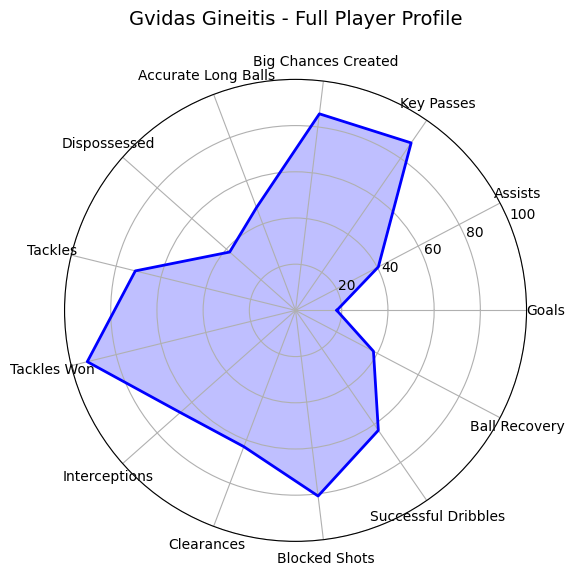

In [ ]:
radar_stats = [
    "ss_goals_per90",
    "ss_assists_per90",
    "ss_keyPasses_per90",
    "ss_bigChancesCreated_per90",
    "ss_accurateLongBalls_per90",
    "ss_possessionLost_per90",
    "ss_tackles_per90",
    "ss_tacklesWon_per90",
    "ss_interceptions_per90",
    "ss_clearances_per90",
    "ss_blockedShots_per90",
    "ss_successfulDribbles_per90",
    "ss_ballRecovery_per90"
]

def percentile_score(midfielders, column):
    return midfielders[column].rank(pct=True) * 100


midfielders["key_passes_score"] = percentile_score(
    midfielders, "ss_keyPasses_per90"
)

midfielders["goals_score"] = percentile_score(
    midfielders, "ss_goals_per90"
)

midfielders["assists_score"] = percentile_score(
    midfielders, "ss_assists_per90"
)

midfielders["big_chances_score"] = percentile_score(
    midfielders, "ss_bigChancesCreated_per90"  
)

midfielders["long_balls_score"] = percentile_score(
    midfielders, "ss_accurateLongBalls_per90"
)

midfielders["dispossessed_score"] = (
    100 - midfielders["ss_possessionLost_per90"].rank(pct=True) * 100
)

midfielders["tackles_score"] = percentile_score(
    midfielders, "ss_tackles_per90"
)

midfielders["tackles_won_score"] = percentile_score(
    midfielders, "ss_tacklesWon_per90"
)

midfielders["interceptions_score"] = percentile_score(
    midfielders, "ss_interceptions_per90"
)

midfielders["clearances_score"] = percentile_score(
    midfielders, "ss_clearances_per90"
)

midfielders["blocked_shots_score"] = percentile_score(
    midfielders, "ss_blockedShots_per90"
)

midfielders["successful_dribbles_score"] = percentile_score(
    midfielders, "ss_successfulDribbles_per90"
)

midfielders["ball_recovery_score"] = percentile_score(
    midfielders, "ss_ballRecovery_per90"
)


labels =[
    "Goals",
    "Assists",
    "Key Passes",
    "Big Chances Created",
    "Accurate Long Balls",
    "Dispossessed",
    "Tackles",
    "Tackles Won",
    "Interceptions",
    "Clearances",
    "Blocked Shots",
    "Successful Dribbles",
    "Ball Recovery"
]

score_columns = [
    "goals_score",
    "assists_score",
    "key_passes_score",
    "big_chances_score",
    "long_balls_score",
    "dispossessed_score",
    "tackles_score",
    "tackles_won_score",
    "interceptions_score",
    "clearances_score",
    "blocked_shots_score",
    "successful_dribbles_score",
    "ball_recovery_score"
]
def radar_plot(player, radar_stats, labels):
    values = player[score_columns].tolist()
    values += values[:1]

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})

    ax.plot(angles, values, color="blue", linewidth=2, linestyle="solid")
    ax.fill(angles, values, color="blue", alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    ax.set_ylim(0, 100)

    ax.set_title(f"{player['player']} - Full Player Profile", size=14, y=1.1)
    plt.show()


def plot_player(player_name):
    player = midfielders[
        midfielders["player"] == player_name
    ].iloc[0]
    
    radar_plot(
        player,
        radar_stats,
        labels
    )
plot_player("Gvidas Gineitis")

Created a percentile system to normalise each players individual stats giving them a score out of 100 based on the other players in the short list. This allows me to plot radar plots for any player of choice and use them to visually compare players together.

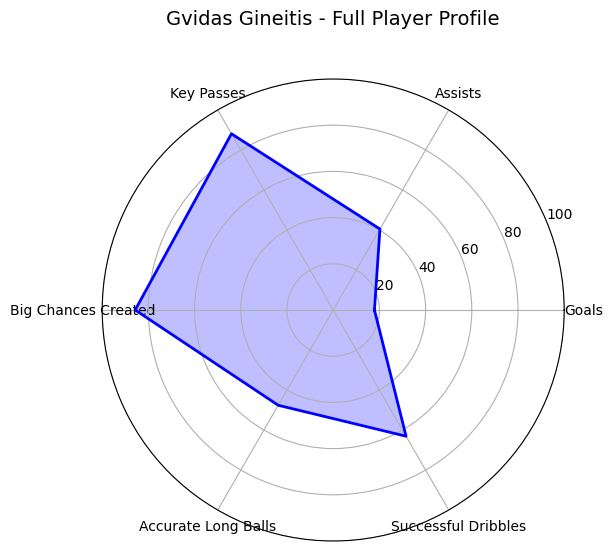

In [ ]:
rel_labels =[
    "Goals",
    "Assists",
    "Key Passes",
    "Big Chances Created",
    "Accurate Long Balls",
    "Successful Dribbles",
   
]

rel_score_columns = [
    "goals_score",
    "assists_score",
    "key_passes_score",
    "big_chances_score",
    "long_balls_score",
    "successful_dribbles_score",
]

def relevant_plot(player, radar_stats, rel_labels):
    values = player[rel_score_columns].tolist()
    values += values[:1]

    angles = np.linspace(0, 2 * np.pi, len(rel_labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})

    ax.plot(angles, values, color="blue", linewidth=2, linestyle="solid")
    ax.fill(angles, values, color="blue", alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(rel_labels)

    ax.set_ylim(0, 100)

    ax.set_title(f"{player['player']} - Full Player Profile", size=14, y=1.1)
    plt.show()

def plot_player(player_name):
    player = midfielders[
        midfielders["player"] == player_name
    ].iloc[0]
    
    relevant_plot(
        player,
        radar_stats,
        rel_labels
    )
plot_player("Gvidas Gineitis")

Since we are looking for a midfielder for a possession oriented team, I have decided to isolate the on-the-ball stats from the off-ball stats. I believe these stats offer much more to a team that wants a player who is good in possession and progressive minded.

In [ ]:
rel_score_columns = [
    "goals_score",
    "assists_score",
    "key_passes_score",
    "big_chances_score",
    "long_balls_score",
    "successful_dribbles_score",
]
weights = {
    "goals_score": 0.10,
    "assists_score": 0.10,
    "key_passes_score": 0.20,
    "big_chances_score": 0.15,
    "long_balls_score": 0.15,
    "successful_dribbles_score": 0.30
}

midfielders["progression_score"] = sum(
    midfielders[col] * weight
    for col, weight in weights.items()
)
midfielders["progression_rank"] = (
    midfielders["progression_score"]
    .rank(ascending=False, method="min")
    .astype(float)
)

top_progressors = midfielders.sort_values(
    "progression_score",
    ascending=False
)

top_progressors[
    ["player", "team", "value_eur", "progression_score"]
].head(10)

,player,team,value_eur,progression_score
1899,Martim Neto,Elche,5000000.0,81.845238
4096,Kamaldeen Sulemana,Atalanta,4200000.0,81.607143
1113,Mateus Mane,Wolves,4300000.0,77.440476
3215,Mamadou Coulibaly,Monaco,4200000.0,73.928571
3245,Junior Mwanga,Nantes,3100000.0,70.535714
4681,Lennon Miller,Udinese,3700000.0,70.238095
5306,Derry Scherhant,Freiburg,4700000.0,68.452381
4645,Emirhan İlkhan,Torino,2100000.0,67.797619
5571,Joel Fujita,St Pauli,3500000.0,66.845238
5474,Arthur,Leverkusen,4700000.0,66.011905


I have now ranked the top 10 candidates that should be considered based on a metric I created called "progression_score" as shown in the table above. This gives each progressive/possession based attribute a weighting as a float in which all weightings add up to one. Weightings shown here: weights = {
    "goals_score": 0.10,
    "assists_score": 0.10,
    "key_passes_score": 0.20,
    "big_chances_score": 0.15,
    "long_balls_score": 0.15,
    "successful_dribbles_score": 0.30
}.
As can be seen, successful dribbles and key passes were given a higher weighting than goals or assist because they constitute more as to what is expected of a progressive midfielder.

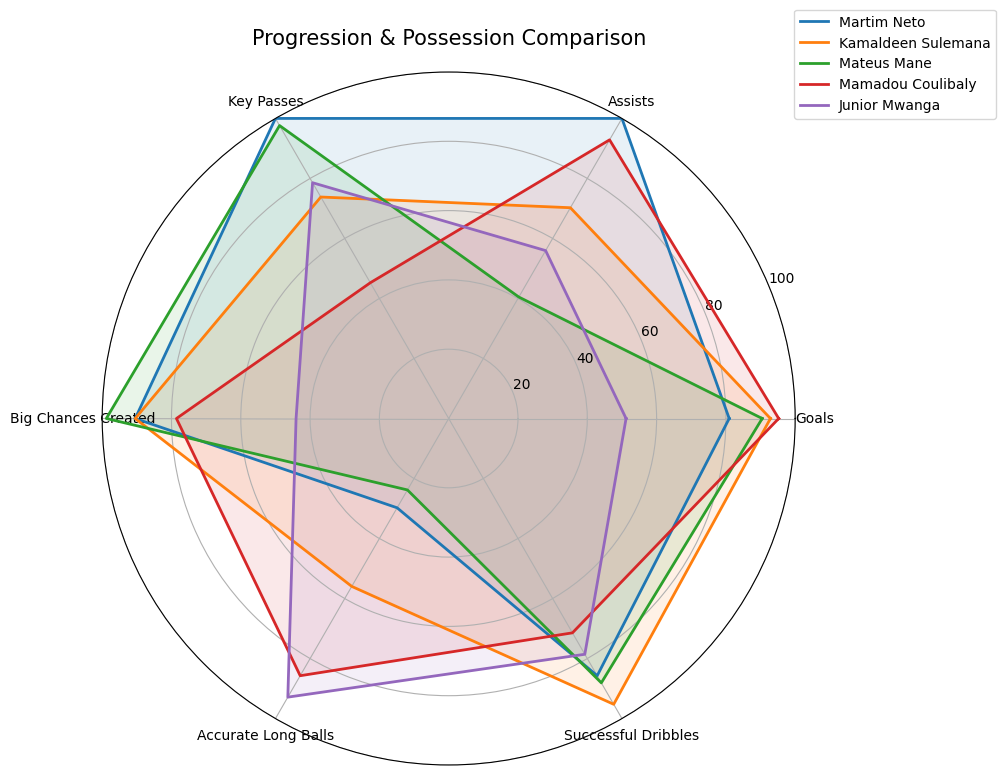

In [ ]:
def compare_players(player_names):
    
   
    labels = [
        "Goals",
        "Assists",
        "Key Passes",
        "Big Chances Created",
        "Accurate Long Balls",
        "Successful Dribbles"
    ]
    
    score_columns = [
        "goals_score",
        "assists_score",
        "key_passes_score",
        "big_chances_score",
        "long_balls_score",
        "successful_dribbles_score"
    ]

    angles = np.linspace(
        0, 2 * np.pi, len(labels), endpoint=False
    ).tolist()
    angles += angles[:1]
    
  
    fig, ax = plt.subplots(
        figsize=(9, 9),
        subplot_kw={"polar": True}
    )
    
 
    for name in player_names:
        
        player = midfielders[
            midfielders["player"] == name
        ].iloc[0]
        
        values = player[score_columns].tolist()
        values += values[:1]
        
        ax.plot(
            angles,
            values,
            linewidth=2,
            label=name
        )
        
        ax.fill(
            angles,
            values,
            alpha=0.1
        )
    
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    
    
    ax.set_ylim(0, 100)
    
    ax.set_title(
        "Progression & Possession Comparison",
        size=15,
        pad=20
    )
    
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.3, 1.1)
    )
    
    plt.show()
top_5 = midfielders.nlargest(
    5,
    "progression_score"
)

players_to_compare = top_5["player"].tolist()

compare_players(players_to_compare)


Added a radar plot with the top 5 players superimposed onto eachother to visually see which attributes certain players possess over others. Now that we have our 5 player shortlist, we can begin analysing video footage of each player and see which one is best suited for the team's style of play.